<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/TCN_ADONN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# ============================================================
# 0) Instalação no Colab
# ============================================================
# No Colab, rode esta célula se faltar algum pacote:
# !pip -q install tensorflow openpyxl scikit-learn matplotlib pandas numpy

import os
import re
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [15]:
# ============================================================
# 1) CONFIGURAÇÕES DO USUÁRIO
# ============================================================

# Opção 1: fazer upload no Colab.
USAR_UPLOAD_COLAB = True

# Opção 2: se não usar upload, informe o caminho do arquivo.
ARQUIVO_EXCEL = "/content/Pressão_Interna.xlsx"

# Ajuste os nomes conforme aparecem na planilha.
COL_PV  = "PV"
COL_G   = "G"
COL_D   = "D"
COL_PCV = "PCV"

# Variável objetivo.
TARGET_COL = COL_PV

# Escolha das entradas:
#
# Para sensor virtual puro, não use PV como entrada:
#FEATURE_COLS = [COL_G, COL_D, COL_PCV]
#
# Para previsão ahead com realimentação de PV, use:
FEATURE_COLS = [COL_PV, COL_G, COL_D, COL_PCV]

# Horizonte de predição.
# HORIZON_STEPS = 1 significa PV(t+1).
# Se Ts = 400 ms, HORIZON_STEPS = 1 equivale a 0,4 s.
HORIZON_STEPS = 10

# Tempo de amostragem dos dados, em segundos.
TS_SECONDS = 0.4

# Janela usada no treinamento.
# A arquitetura abaixo tem receptive field = 7.
# Use WINDOW >= 7.
WINDOW = 16

# Separação temporal.
TRAIN_FRAC = 0.70

# Hiperparâmetros da TCN.
N_FILTERS = 4
KERNEL_SIZE = 3
EPOCHS = 150
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
PATIENCE = 15

# Pasta de saída.
OUT_DIR = "saida_tcn_contrologix"


In [16]:

# ============================================================
# 2) FUNÇÕES AUXILIARES
# ============================================================

def safe_st_name(name: str) -> str:
    """
    Converte nome de coluna para nome seguro de tag no Studio 5000.
    """
    s = str(name).strip()
    s = re.sub(r"[^0-9a-zA-Z_]", "_", s)
    if re.match(r"^[0-9]", s):
        s = "X_" + s
    return s.upper()


def fmt(x: float) -> str:
    """
    Formata número REAL para ST.
    """
    if abs(x) < 1e-14:
        x = 0.0
    return f"{float(x):.12g}"


def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))


def carregar_excel():
    if USAR_UPLOAD_COLAB:
        try:
            from google.colab import files
            uploaded = files.upload()
            if len(uploaded) == 0:
                raise RuntimeError("Nenhum arquivo enviado.")
            fname = list(uploaded.keys())[0]
            return pd.read_excel(fname), fname
        except Exception as e:
            print("Falha no upload do Colab. Tentando ARQUIVO_EXCEL local.")
            print(e)

    return pd.read_excel(ARQUIVO_EXCEL), ARQUIVO_EXCEL


def preparar_dataframe(df):
    cols_needed = list(dict.fromkeys(FEATURE_COLS + [TARGET_COL]))
    print("Colunas disponíveis:")
    print(list(df.columns))
    print("\nColunas usadas:", cols_needed)

    for c in cols_needed:
        if c not in df.columns:
            raise ValueError(f"Coluna não encontrada: {c}")

    d = df[cols_needed].copy()
    for c in cols_needed:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    d = d.dropna().reset_index(drop=True)
    return d


def criar_janelas(features_z, target_z, window, horizon_steps, raw_train_end):
    """
    Cria janelas temporais.
    X termina no instante t.
    y é target(t + horizon_steps).
    A separação treino/validação é temporal, usando o índice do alvo.
    """
    X, y, target_indices = [], [], []
    n = len(target_z)
    last_start = n - window - horizon_steps

    for s in range(last_start + 1):
        end = s + window
        target_idx = end - 1 + horizon_steps
        X.append(features_z[s:end, :])
        y.append(target_z[target_idx])
        target_indices.append(target_idx)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1, 1)
    target_indices = np.asarray(target_indices)

    train_mask = target_indices < raw_train_end
    val_mask = ~train_mask

    return X[train_mask], y[train_mask], X[val_mask], y[val_mask], target_indices[train_mask], target_indices[val_mask]


def construir_modelo(n_features):
    inp = layers.Input(shape=(WINDOW, n_features), name="input_window")

    x = layers.Conv1D(
        filters=N_FILTERS,
        kernel_size=KERNEL_SIZE,
        dilation_rate=1,
        padding="causal",
        activation="relu",
        name="conv1"
    )(inp)

    x = layers.Conv1D(
        filters=N_FILTERS,
        kernel_size=KERNEL_SIZE,
        dilation_rate=2,
        padding="causal",
        activation="relu",
        name="conv2"
    )(x)

    # Pega somente a última amostra da sequência.
    x = layers.Lambda(lambda z: z[:, -1, :], name="last_step")(x)

    out = layers.Dense(1, activation="linear", name="dense")(x)

    model = models.Model(inp, out)
    opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return model


def gerar_st_code(model, feature_cols, feature_mean, feature_std, target_mean, target_std):
    """
    Gera código ST sem arrays, com coeficientes hardcoded.
    A ordem dos pesos é ajustada para causalidade:
    - Lag 0 = amostra atual.
    - Lag 1 = uma amostra anterior.
    - Lag 2 = duas amostras anteriores.
    """

    st_features = [safe_st_name(c) for c in feature_cols]

    W1, b1 = model.get_layer("conv1").get_weights()
    W2, b2 = model.get_layer("conv2").get_weights()
    Wd, bd = model.get_layer("dense").get_weights()

    # Keras Conv1D weights: (kernel, in_channels, filters)
    # ST usará lag 0 como atual. Em padding causal:
    # kernel[K-1] = lag 0
    # kernel[K-2] = lag 1
    # kernel[K-3] = lag 2

    lines = []
    lines.append("============================================================")
    lines.append("AOI_TCN_SIMPLE_STREAMING")
    lines.append("TCN simples para ControlLogix / Studio 5000")
    lines.append("")
    lines.append("Este arquivo foi gerado automaticamente pelo Python.")
    lines.append("Copie a seção 'CÓDIGO STRUCTURED TEXT' para a rotina ST da AOI.")
    lines.append("")
    lines.append("Arquitetura:")
    lines.append(f"- Entradas: {', '.join(st_features)}")
    lines.append(f"- Saída: {safe_st_name(TARGET_COL)}_HAT")
    lines.append(f"- Horizonte: {HORIZON_STEPS} passo(s) = {HORIZON_STEPS * TS_SECONDS:.3f} s")
    lines.append(f"- Conv1D causal: filtros={N_FILTERS}, kernel=3, dilation=1, ReLU")
    lines.append(f"- Conv1D causal: filtros={N_FILTERS}, kernel=3, dilation=2, ReLU")
    lines.append("- Dense linear")
    lines.append("- Normalização: z = (x - média) / desvio padrão")
    lines.append("============================================================")
    lines.append("")
    lines.append("")
    lines.append("============================================================")
    lines.append("INPUT PARAMETERS")
    lines.append("============================================================")
    for f in st_features:
        lines.append(f"{f}_IN              REAL")
    lines.append("SampleTrig          BOOL")
    lines.append("Reset               BOOL")
    lines.append("Hold                BOOL")
    lines.append("")
    lines.append("============================================================")
    lines.append("OUTPUT PARAMETERS")
    lines.append("============================================================")
    lines.append("Y_Hat               REAL")
    lines.append("Yz_Pred_Out         REAL")
    lines.append("Valid               BOOL")
    lines.append("SampleCount         DINT")
    lines.append("ScanCount           DINT")
    lines.append("Status              DINT")
    lines.append("HorizonSteps        DINT")
    lines.append("Horizon_s           REAL")
    lines.append("")
    lines.append("============================================================")
    lines.append("LOCAL TAGS")
    lines.append("============================================================")
    lines.append("SampleTrig_Old      BOOL")
    lines.append("SamplePulse         BOOL")
    lines.append("")
    for f in st_features:
        lines.append(f"{f}_NEW              REAL")
        lines.append(f"{f}_0                REAL")
        lines.append(f"{f}_1                REAL")
        lines.append(f"{f}_2                REAL")
    lines.append("")
    for i in range(N_FILTERS):
        lines.append(f"H1_{i}_NEXT          REAL")
        for lag in range(5):
            lines.append(f"H1_{i}_{lag}             REAL")
    lines.append("")
    for i in range(N_FILTERS):
        lines.append(f"H2_{i}               REAL")
    lines.append("Yz_Pred             REAL")
    lines.append("")
    lines.append("============================================================")
    lines.append("CÓDIGO STRUCTURED TEXT")
    lines.append("============================================================")
    lines.append("")

    c = []

    c.append("// =======================================================")
    c.append("// AOI_TCN_SIMPLE_STREAMING")
    c.append("// Structured Text - Studio 5000 / ControlLogix")
    c.append("//")
    c.append("// TCN simples, causal, streaming.")
    c.append("// O treinamento foi feito offline em Python.")
    c.append("// O PLC executa apenas inferencia.")
    c.append("//")
    c.append("// Status:")
    c.append("// 0 = Reset ativo")
    c.append("// 1 = Calculo valido")
    c.append("// 2 = Historico em inicializacao")
    c.append("// 3 = Hold ativo")
    c.append("// 4 = Aguardando pulso de amostragem")
    c.append("// =======================================================")
    c.append("")
    c.append(f"HorizonSteps := {int(HORIZON_STEPS)};")
    c.append(f"Horizon_s := {fmt(HORIZON_STEPS * TS_SECONDS)};")
    c.append("")
    c.append("IF ScanCount < 2147483647 THEN")
    c.append("    ScanCount := ScanCount + 1;")
    c.append("END_IF;")
    c.append("")
    c.append("SamplePulse := SampleTrig AND NOT SampleTrig_Old;")
    c.append("SampleTrig_Old := SampleTrig;")
    c.append("")
    c.append("IF Reset THEN")
    c.append("")
    c.append("    Y_Hat := 0.0;")
    c.append("    Yz_Pred := 0.0;")
    c.append("    Yz_Pred_Out := 0.0;")
    c.append("    SampleCount := 0;")
    c.append("    Valid := SampleCount > 2147483647;")
    c.append("    Status := 0;")
    c.append("")
    for f in st_features:
        c.append(f"    {f}_NEW := 0.0;")
        c.append(f"    {f}_0 := 0.0;")
        c.append(f"    {f}_1 := 0.0;")
        c.append(f"    {f}_2 := 0.0;")
    for i in range(N_FILTERS):
        c.append(f"    H1_{i}_NEXT := 0.0;")
        for lag in range(5):
            c.append(f"    H1_{i}_{lag} := 0.0;")
    for i in range(N_FILTERS):
        c.append(f"    H2_{i} := 0.0;")
    c.append("")
    c.append("ELSIF Hold THEN")
    c.append("")
    c.append("    Status := 3;")
    c.append("")
    c.append("ELSE")
    c.append("")
    c.append("    IF SamplePulse THEN")
    c.append("")
    c.append("        // Normalizacao das entradas atuais")
    for idx, f in enumerate(st_features):
        c.append(f"        {f}_NEW := ({f}_IN - {fmt(feature_mean[idx])}) / {fmt(feature_std[idx])};")
    c.append("")
    c.append("        // Atualizacao dos historicos de entrada")
    c.append("        IF SampleCount = 0 THEN")
    for f in st_features:
        c.append(f"            {f}_0 := {f}_NEW;")
        c.append(f"            {f}_1 := {f}_NEW;")
        c.append(f"            {f}_2 := {f}_NEW;")
    c.append("        ELSE")
    for f in st_features:
        c.append(f"            {f}_2 := {f}_1;")
        c.append(f"            {f}_1 := {f}_0;")
        c.append(f"            {f}_0 := {f}_NEW;")
    c.append("        END_IF;")
    c.append("")
    c.append("        // Camada 1: Conv1D causal, dilation=1, ReLU")

    # H1 expressions
    for fidx in range(N_FILTERS):
        terms = [fmt(b1[fidx])]
        for cidx, fname in enumerate(st_features):
            for lag in range(KERNEL_SIZE):
                coeff = W1[KERNEL_SIZE - 1 - lag, cidx, fidx]
                terms.append(f"({fmt(coeff)} * {fname}_{lag})")
        expr = " + ".join(terms)
        c.append(f"        H1_{fidx}_NEXT := {expr};")
        c.append(f"        IF H1_{fidx}_NEXT < 0.0 THEN")
        c.append(f"            H1_{fidx}_NEXT := 0.0;")
        c.append("        END_IF;")
    c.append("")
    c.append("        // Atualizacao do historico da camada H1")
    c.append("        IF SampleCount = 0 THEN")
    for fidx in range(N_FILTERS):
        for lag in range(5):
            c.append(f"            H1_{fidx}_{lag} := H1_{fidx}_NEXT;")
    c.append("        ELSE")
    for fidx in range(N_FILTERS):
        c.append(f"            H1_{fidx}_4 := H1_{fidx}_3;")
        c.append(f"            H1_{fidx}_3 := H1_{fidx}_2;")
        c.append(f"            H1_{fidx}_2 := H1_{fidx}_1;")
        c.append(f"            H1_{fidx}_1 := H1_{fidx}_0;")
        c.append(f"            H1_{fidx}_0 := H1_{fidx}_NEXT;")
    c.append("        END_IF;")
    c.append("")
    c.append("        // Camada 2: Conv1D causal, dilation=2, ReLU")
    c.append("        // Usa H1 atual, H1 de 2 amostras atras e H1 de 4 amostras atras.")

    # H2 expressions
    # Keras W2: (kernel, input_filters, output_filters)
    # lag 0 -> kernel index 2, use H1_g_0
    # lag 2 -> kernel index 1, use H1_g_2
    # lag 4 -> kernel index 0, use H1_g_4
    lag_map = [(0, 0), (1, 2), (2, 4)]  # kernel lag index, H1 tag lag
    for out_f in range(N_FILTERS):
        terms = [fmt(b2[out_f])]
        for in_f in range(N_FILTERS):
            for kernel_lag, hlag in lag_map:
                coeff = W2[KERNEL_SIZE - 1 - kernel_lag, in_f, out_f]
                terms.append(f"({fmt(coeff)} * H1_{in_f}_{hlag})")
        expr = " + ".join(terms)
        c.append(f"        H2_{out_f} := {expr};")
        c.append(f"        IF H2_{out_f} < 0.0 THEN")
        c.append(f"            H2_{out_f} := 0.0;")
        c.append("        END_IF;")
    c.append("")
    c.append("        // Saida linear no dominio normalizado")
    terms = [fmt(float(bd[0]))]
    for fidx in range(N_FILTERS):
        coeff = Wd[fidx, 0]
        terms.append(f"({fmt(coeff)} * H2_{fidx})")
    c.append(f"        Yz_Pred := {' + '.join(terms)};")
    c.append("        Yz_Pred_Out := Yz_Pred;")
    c.append("")
    c.append("        // Desnormalizacao da saida")
    c.append(f"        Y_Hat := {fmt(target_mean)} + {fmt(target_std)} * Yz_Pred;")
    c.append("")
    c.append("        IF SampleCount < 2147483647 THEN")
    c.append("            SampleCount := SampleCount + 1;")
    c.append("        END_IF;")
    c.append("")
    c.append("        // Receptive field da TCN = 7 amostras")
    c.append("        Valid := SampleCount >= 7;")
    c.append("")
    c.append("        IF SampleCount >= 7 THEN")
    c.append("            Status := 1;")
    c.append("        ELSE")
    c.append("            Status := 2;")
    c.append("        END_IF;")
    c.append("")
    c.append("    ELSE")
    c.append("")
    c.append("        Valid := SampleCount >= 7;")
    c.append("        IF SampleCount >= 7 THEN")
    c.append("            Status := 1;")
    c.append("        ELSE")
    c.append("            Status := 4;")
    c.append("        END_IF;")
    c.append("")
    c.append("    END_IF;")
    c.append("")
    c.append("END_IF;")
    c.append("")

    return "\n".join(lines + c)


In [17]:
# ============================================================
# 3) EXECUÇÃO DO TREINAMENTO
# ============================================================

os.makedirs(OUT_DIR, exist_ok=True)

df_raw, fname = carregar_excel()
df = preparar_dataframe(df_raw)

raw_train_end = int(len(df) * TRAIN_FRAC)

feature_data = df[FEATURE_COLS].values.astype(float)
target_data = df[TARGET_COL].values.astype(float).reshape(-1, 1)

feature_mean = feature_data[:raw_train_end].mean(axis=0)
feature_std = feature_data[:raw_train_end].std(axis=0)
feature_std[feature_std < 1e-12] = 1.0

target_mean = target_data[:raw_train_end].mean(axis=0)[0]
target_std = target_data[:raw_train_end].std(axis=0)[0]
if target_std < 1e-12:
    target_std = 1.0

features_z = (feature_data - feature_mean) / feature_std
target_z = (target_data[:, 0] - target_mean) / target_std

X_train, y_train, X_val, y_val, idx_train, idx_val = criar_janelas(
    features_z,
    target_z,
    WINDOW,
    HORIZON_STEPS,
    raw_train_end
)

print("\nResumo dos dados:")
print("Arquivo:", fname)
print("Amostras brutas:", len(df))
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("FEATURE_COLS:", FEATURE_COLS)
print("TARGET_COL:", TARGET_COL)
print("Horizonte:", HORIZON_STEPS, "passo(s) =", HORIZON_STEPS * TS_SECONDS, "s")

model = construir_modelo(n_features=len(FEATURE_COLS))
model.summary()

cb = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=max(5, PATIENCE // 3),
        min_lr=1e-6
    )
]

hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    verbose=1
)


Saving Pressão_Interna.xlsx to Pressão_Interna (3).xlsx
Colunas disponíveis:
['PV', 'G', 'D', 'PCV']

Colunas usadas: ['PV', 'G', 'D', 'PCV']

Resumo dos dados:
Arquivo: Pressão_Interna (3).xlsx
Amostras brutas: 156588
X_train: (109586, 16, 4)
X_val: (46977, 16, 4)
FEATURE_COLS: ['PV', 'G', 'D', 'PCV']
TARGET_COL: PV
Horizonte: 10 passo(s) = 4.0 s


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_window (InputLayer)       │ (None, 16, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 16, 4)          │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 16, 4)          │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_step (Lambda)              │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109 (436.00 B)

 Trainable params: 109 (436.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.3936 - mae: 0.4411 - val_loss: 0.2021 - val_mae: 0.3542 - learning_rate: 0.0010
Epoch 2/150
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0786 - mae: 0.2165 - val_loss: 0.1098 - val_mae: 0.2571 - learning_rate: 0.0010
Epoch 3/150
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0483 - mae: 0.1685 - val_loss: 0.0589 - val_mae: 0.1863 - learning_rate: 0.0010
Epoch 4/150
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0304 - mae: 0.1324 - val_loss: 0.0389 - val_mae: 0.1494 - learning_rate: 0.0010
Epoch 5/150
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0253 - mae: 0.1200 - val_loss: 0.0357 - val_mae: 0.1384 - learning_rate: 0.0010
Epoch 6/150
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0235 - mae: 0.1153 - val_loss: 0.0352 - val_mae: 0.1420 - learning_rate: 0.0010
Epoch 7/150
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0223 - mae: 0.1124 - val_loss: 0.0345 - val_mae: 0.1413 - learning_rate: 0.0010

In [18]:
# ============================================================
# 4) AVALIAÇÃO
# ============================================================

pred_train_z = model.predict(X_train, verbose=0).reshape(-1)
pred_val_z = model.predict(X_val, verbose=0).reshape(-1)

y_train_real = target_mean + target_std * y_train.reshape(-1)
y_val_real = target_mean + target_std * y_val.reshape(-1)

pred_train_real = target_mean + target_std * pred_train_z
pred_val_real = target_mean + target_std * pred_val_z

metrics = {
    "arquivo": fname,
    "feature_cols": FEATURE_COLS,
    "target_col": TARGET_COL,
    "horizon_steps": HORIZON_STEPS,
    "horizon_seconds": HORIZON_STEPS * TS_SECONDS,
    "window": WINDOW,
    "n_filters": N_FILTERS,
    "kernel_size": KERNEL_SIZE,
    "rmse_train": rmse(y_train_real, pred_train_real),
    "mae_train": mean_absolute_error(y_train_real, pred_train_real),
    "r2_train": r2_score(y_train_real, pred_train_real),
    "rmse_val": rmse(y_val_real, pred_val_real),
    "mae_val": mean_absolute_error(y_val_real, pred_val_real),
    "r2_val": r2_score(y_val_real, pred_val_real),
}

print("\nMétricas:")
for k, v in metrics.items():
    print(k, ":", v)

pd.DataFrame([metrics]).to_csv(os.path.join(OUT_DIR, "metricas_tcn.csv"), index=False)

norm = {
    "feature_cols": FEATURE_COLS,
    "feature_mean": feature_mean.tolist(),
    "feature_std": feature_std.tolist(),
    "target_col": TARGET_COL,
    "target_mean": float(target_mean),
    "target_std": float(target_std),
    "horizon_steps": int(HORIZON_STEPS),
    "ts_seconds": float(TS_SECONDS),
    "window": int(WINDOW),
    "n_filters": int(N_FILTERS),
}
with open(os.path.join(OUT_DIR, "normalizacao_tcn.json"), "w", encoding="utf-8") as f:
    json.dump(norm, f, indent=2, ensure_ascii=False)




Métricas:
arquivo : Pressão_Interna (3).xlsx
feature_cols : ['PV', 'G', 'D', 'PCV']
target_col : PV
horizon_steps : 10
horizon_seconds : 4.0
window : 16
n_filters : 4
kernel_size : 3
rmse_train : 0.04059549796299683
mae_train : 0.030357616859223117
r2_train : 0.9850162216010745
rmse_val : 0.049740217685418996
mae_val : 0.036871692847589635
r2_val : 0.9454221876722914


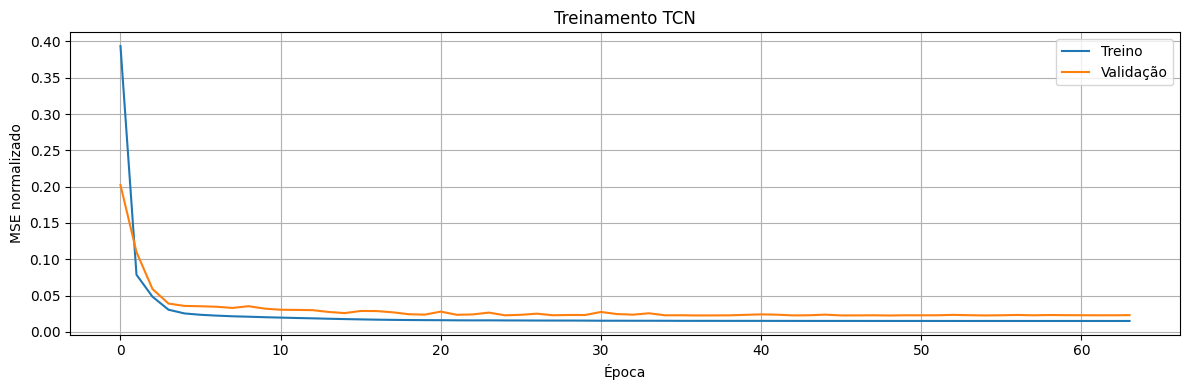

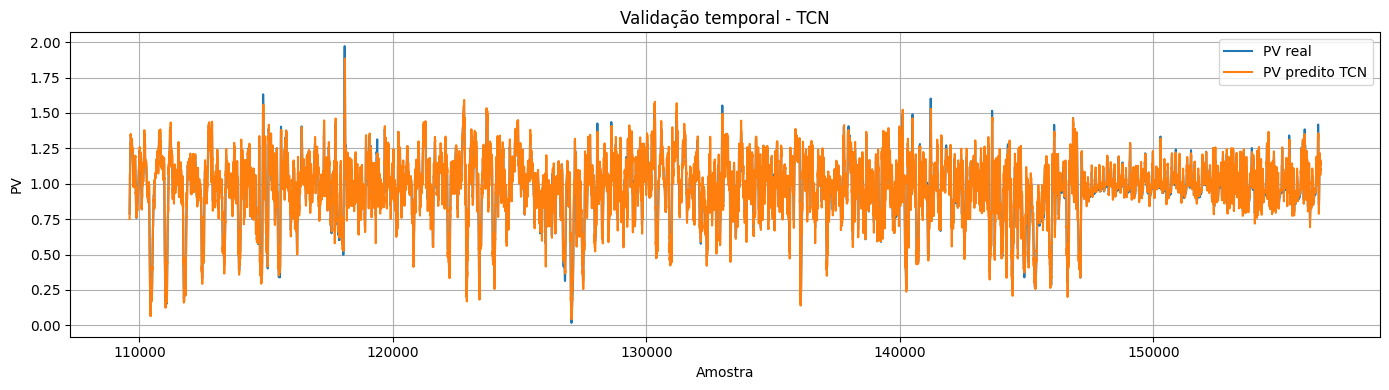

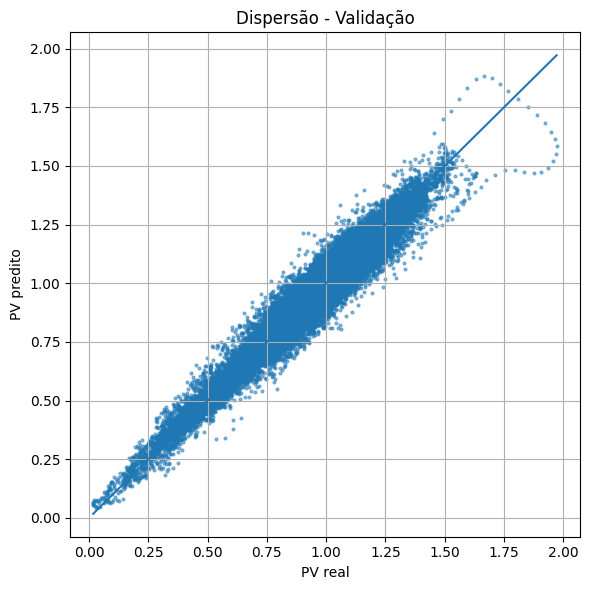

In [19]:
# ============================================================
# 5) GRÁFICOS
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(hist.history["loss"], label="Treino")
plt.plot(hist.history["val_loss"], label="Validação")
plt.xlabel("Época")
plt.ylabel("MSE normalizado")
plt.title("Treinamento TCN")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "grafico_treinamento_loss.png"), dpi=160)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(idx_val, y_val_real, label="PV real")
plt.plot(idx_val, pred_val_real, label="PV predito TCN")
plt.xlabel("Amostra")
plt.ylabel(TARGET_COL)
plt.title("Validação temporal - TCN")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "grafico_validacao_tcn.png"), dpi=160)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_val_real, pred_val_real, s=4, alpha=0.5)
mn = min(np.min(y_val_real), np.min(pred_val_real))
mx = max(np.max(y_val_real), np.max(pred_val_real))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("PV real")
plt.ylabel("PV predito")
plt.title("Dispersão - Validação")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "grafico_dispersao_validacao_tcn.png"), dpi=160)
plt.show()



In [20]:

# ============================================================
# 6) EXPORTAÇÃO DO CÓDIGO ST PARA CONTROLLOGIX
# ============================================================

st_code = gerar_st_code(
    model=model,
    feature_cols=FEATURE_COLS,
    feature_mean=feature_mean,
    feature_std=feature_std,
    target_mean=target_mean,
    target_std=target_std
)

st_path = os.path.join(OUT_DIR, "AOI_TCN_SIMPLE_STREAMING_ST.txt")
with open(st_path, "w", encoding="utf-8") as f:
    f.write(st_code)

# Salva o modelo Keras também.
model.save(os.path.join(OUT_DIR, "modelo_tcn.keras"))

print("\nArquivos gerados em:", OUT_DIR)
print("- metricas_tcn.csv")
print("- normalizacao_tcn.json")
print("- grafico_treinamento_loss.png")
print("- grafico_validacao_tcn.png")
print("- grafico_dispersao_validacao_tcn.png")
print("- AOI_TCN_SIMPLE_STREAMING_ST.txt")
print("- modelo_tcn.keras")

try:
    from google.colab import files
    import shutil
    zip_name = "saida_tcn_contrologix.zip"
    shutil.make_archive("saida_tcn_contrologix", "zip", OUT_DIR)
    files.download(zip_name)
except Exception:
    pass



Arquivos gerados em: saida_tcn_contrologix
- metricas_tcn.csv
- normalizacao_tcn.json
- grafico_treinamento_loss.png
- grafico_validacao_tcn.png
- grafico_dispersao_validacao_tcn.png
- AOI_TCN_SIMPLE_STREAMING_ST.txt
- modelo_tcn.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>